<a href="https://colab.research.google.com/github/vedaanshi2111-debug/Arraysofobject-/blob/main/statsmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --quiet pmdarima statsmodels matplotlib pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [4]:
# Generate synthetic monthly time series
# Create a monthly date index for periods points.
# Build a linear trend component and a yearly seasonal component.
# Add Gaussian noise to make the series realistic

In [5]:
periods = 120
time_index = pd.date_range("2015-01-01", periods=periods, freq="M")
trend = np.linspace(50, 120, periods)
season = 10 * np.sin(2 * np.pi * time_index.month / 12)
noise = np.random.normal(0, 5, periods)

ts = trend + season + noise

/tmp/ipykernel_7842/1042581877.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_index = pd.date_range("2015-01-01", periods=periods, freq="M")


In [8]:
# Create DataFrame
# Put the generated series into a pandas DataFrame with a Date index.
# Setting the Date as index is important for plotting, resampling and time aware operations
df = pd.DataFrame({'value': ts}, index=time_index)

In [9]:
data = pd.DataFrame({"Date": time_index, "Value": ts})
data.set_index("Date", inplace=True)
data.head()

,Value
Date,
2015-01-31,52.741429
2015-02-28,60.533617
2015-03-31,60.013333
2015-04-30,66.126697
2015-05-31,52.015746


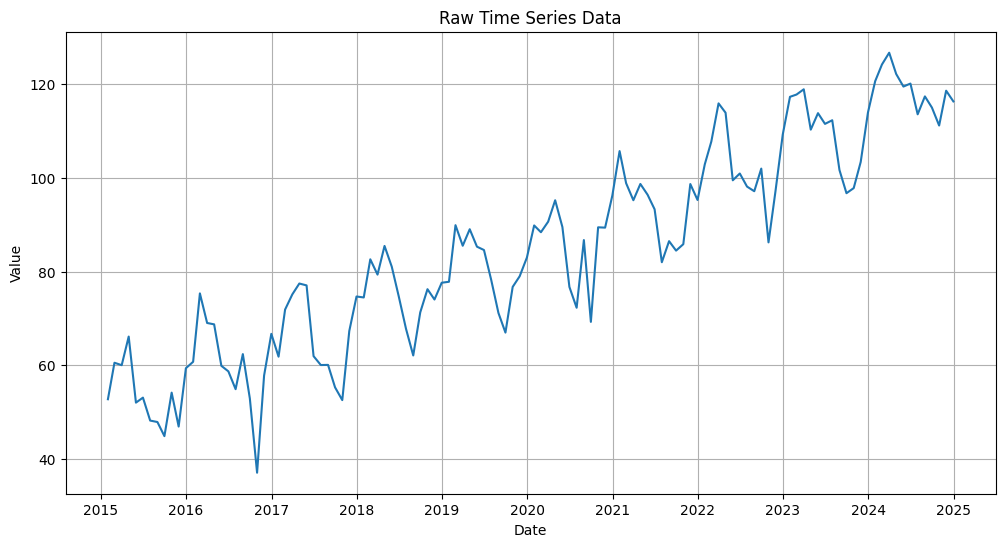

In [11]:
# Visualize the raw time series
# Plot the observed series to inspect trend and seasonality.
# A quick visual check helps decide preprocessing and modelling choices

plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title('Raw Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

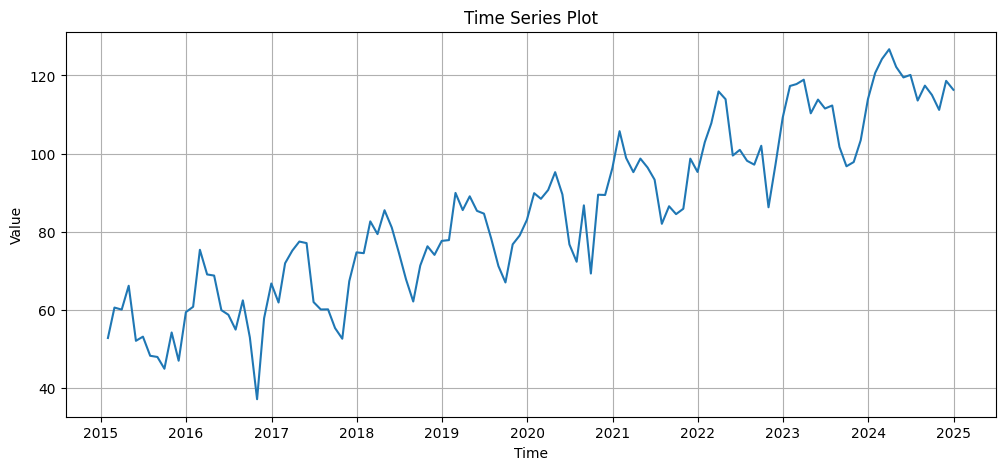

In [12]:
plt.figure(figsize=(12,5))
plt.plot(data.Value)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()